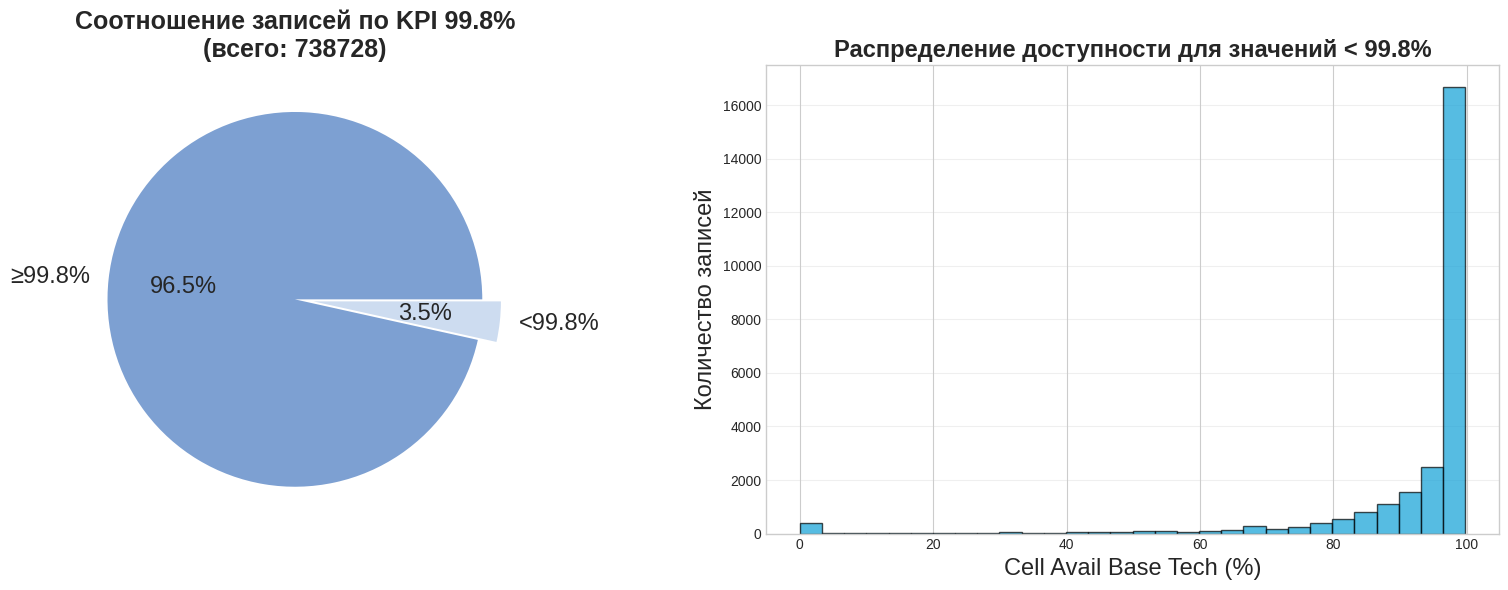

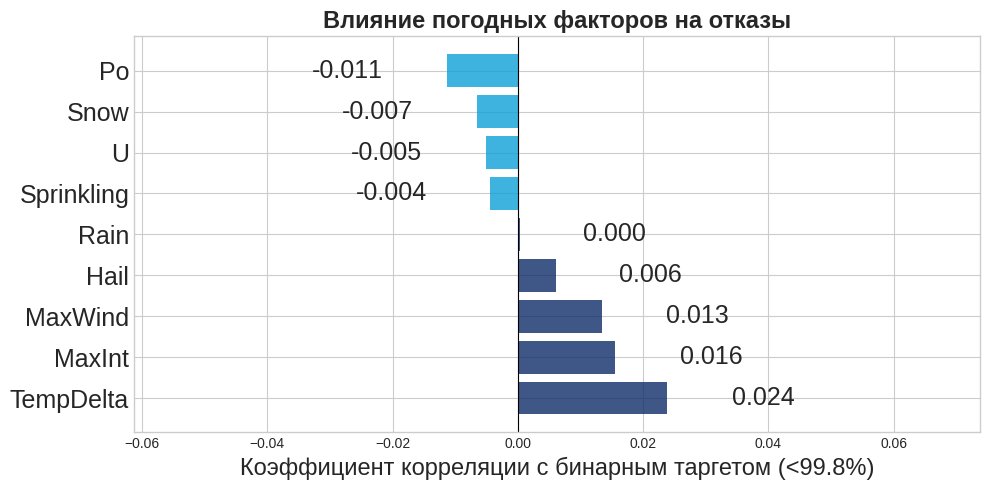

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

kpi_threshold = 99.8
df['target_binary'] = (df['Cell Avail Base Tech (%)'] < kpi_threshold).astype(int)

df_problems = df[df['Cell Avail Base Tech (%)'] < kpi_threshold].copy()

fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6))

count_good = (df['Cell Avail Base Tech (%)'] >= kpi_threshold).sum()
count_bad = (df['Cell Avail Base Tech (%)'] < kpi_threshold).sum()
total = len(df)

axes1[0].pie([count_good, count_bad],
             labels=[f'≥{kpi_threshold}%', f'<{kpi_threshold}%'],
             autopct='%1.1f%%',
             colors=['#7DA0D2', '#CDDCF0'],
             explode=[0, 0.1],
             textprops={'fontsize': 17})
axes1[0].set_title(f'Соотношение записей по KPI {kpi_threshold}%\n(всего: {total})', fontsize=18, fontweight='bold')

if len(df_problems) > 0:
    axes1[1].hist(df_problems['Cell Avail Base Tech (%)'].dropna(),
                  bins=30, edgecolor='black', alpha=0.7, color='#0FA0D7')
    axes1[1].set_xlabel('Cell Avail Base Tech (%)', fontsize=17)
    axes1[1].set_ylabel('Количество записей', fontsize=17)
    axes1[1].set_title(f'Распределение доступности для значений < {kpi_threshold}%', fontsize=17, fontweight='bold')
    axes1[1].grid(True, alpha=0.3, axis='y')
else:
    axes1[1].text(0.5, 0.5, f'Нет записей с доступностью < {kpi_threshold}%',
                  ha='center', va='center', fontsize=12, transform=axes1[1].transAxes)

plt.tight_layout()
plt.savefig('eda_slide1.png', dpi=300, bbox_inches='tight')
plt.show()

if len(weather_cols) > 0:
    corr_with_target = []
    for col in weather_cols:
        corr_val = df['target_binary'].corr(df[col])
        corr_with_target.append(corr_val)

    corr_series = pd.Series(corr_with_target, index=weather_cols).sort_values(ascending=False)

    colors = ['#0F2D69' if x > 0 else '#0FA0D7' for x in corr_series.values]

    margin = max(0.05, (corr_series.max() - corr_series.min()) * 0.1)
    x_min = corr_series.min() - margin
    x_max = corr_series.max() + margin

    fig2, ax2 = plt.subplots(figsize=(10, max(5, len(weather_cols)*0.4)))
    ax2.barh(range(len(corr_series)), corr_series.values, color=colors, alpha=0.8)
    ax2.set_yticks(range(len(corr_series)))
    ax2.set_yticklabels(corr_series.index, fontsize=18)
    ax2.axvline(x=0, color='black', linewidth=0.8)
    ax2.set_xlabel(f'Коэффициент корреляции с бинарным таргетом (<{kpi_threshold}%)', fontsize=17)
    ax2.set_title('Влияние погодных факторов на отказы', fontsize=17, fontweight='bold')
    ax2.set_xlim(x_min, x_max)  
    ax2.tick_params(axis='x', labelsize=10)

    for i, v in enumerate(corr_series.values):
        offset = abs(v) * 0.02 + 0.01
        if v > 0:
            ax2.text(v + offset, i, f'{v:.3f}', va='center', ha='left', fontsize=18)
        else:
            ax2.text(v - offset, i, f'{v:.3f}', va='center', ha='right', fontsize=18)

    plt.tight_layout()
    plt.savefig('eda_slide2_correlations.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Нет погодных признаков для анализа корреляций.")

Размер Train: (591643, 140), Размер Test: (147085, 140)


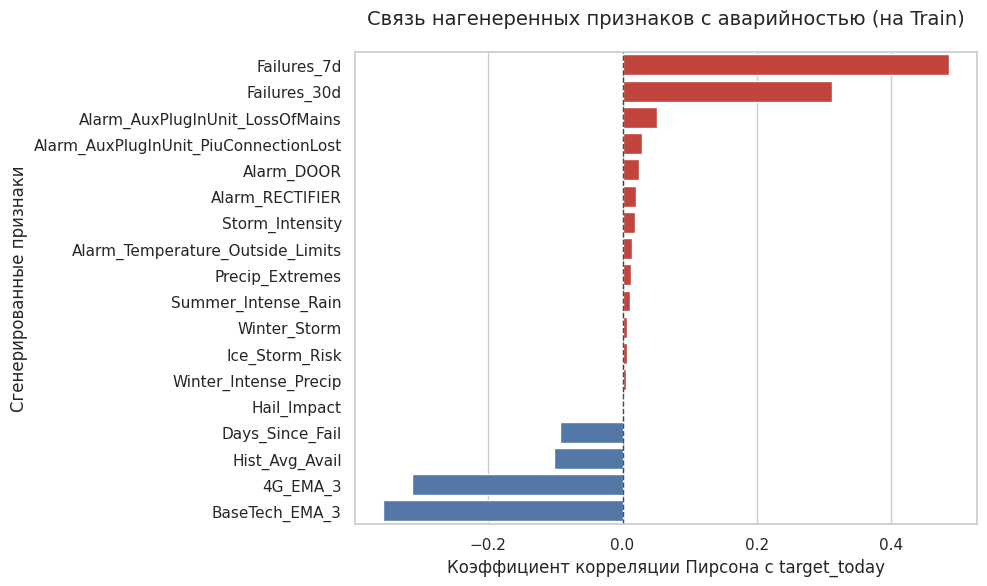

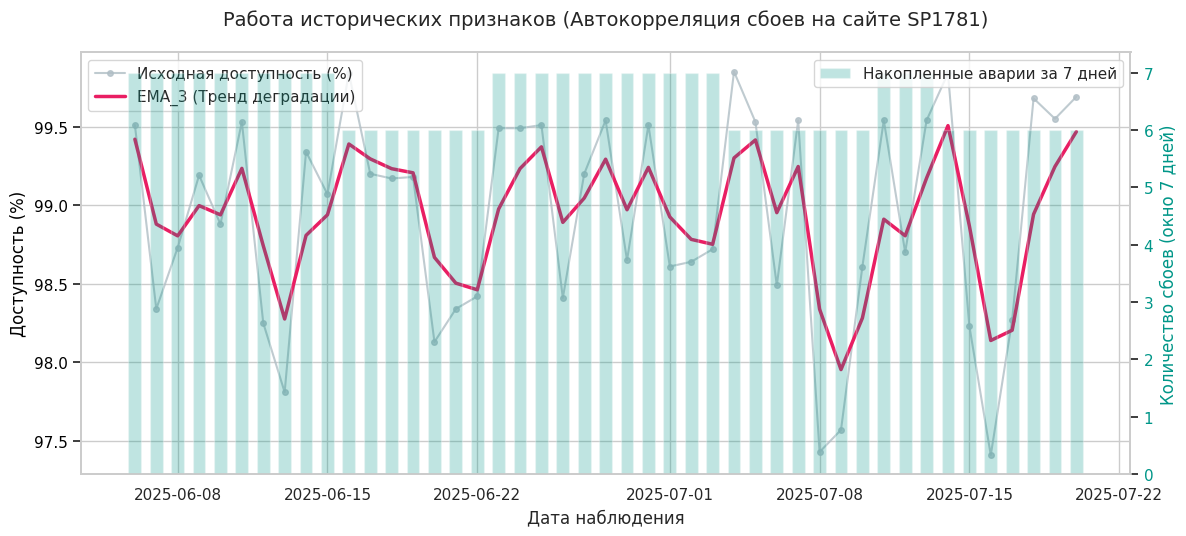

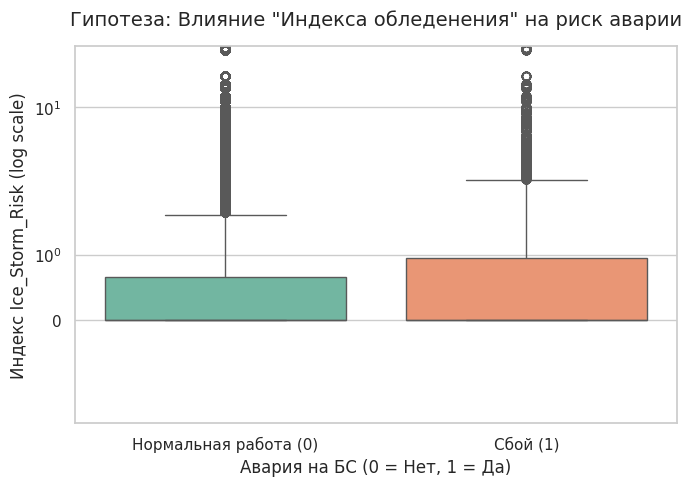

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Настройка стиля для красивых графиков
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# =====================================================================
# 1. ИНИЦИАЛИЗАЦИЯ И БАЗОВАЯ ПОДГОТОВКА
# =====================================================================
df = df_main_with_weather.copy()

# Целевая переменная: 1 если была авария (доступность ниже 99.8%), иначе 0
df['target_today'] = (df['Cell Avail Base Tech (%)'] < 99.8).astype(int)

# Преобразование дат и обязательная сортировка для корректной работы исторических фичей
df['RECDATE'] = pd.to_datetime(df['RECDATE'])
df = df.sort_values(['Master Site', 'RECDATE']).reset_index(drop=True)

# =====================================================================
# 2. СЕЗОННОСТЬ И ВРЕМЯ (Циклическое кодирование)
# =====================================================================
df['day_of_week'] = df['RECDATE'].dt.dayofweek
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

df['day_of_month'] = df['RECDATE'].dt.day
df['day_month_sin'] = np.sin(2 * np.pi * df['day_of_month'] / 31)
df['day_month_cos'] = np.cos(2 * np.pi * df['day_of_month'] / 31)

df['month'] = df['RECDATE'].dt.month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df['quarter'] = df['RECDATE'].dt.quarter
df['quarter_sin'] = np.sin(2 * np.pi * df['quarter'] / 4)
df['quarter_cos'] = np.cos(2 * np.pi * df['quarter'] / 4)

df['season'] = df['month'].map({
    12: 'winter', 1: 'winter', 2: 'winter',
    3: 'spring', 4: 'spring', 5: 'spring',
    6: 'summer', 7: 'summer', 8: 'summer',
    9: 'autumn', 10: 'autumn', 11: 'autumn'
})

season_num_map = {'winter': 0, 'spring': 1, 'summer': 2, 'autumn': 3}
df['season_num'] = df['season'].map(season_num_map)
df['season_sin'] = np.sin(2 * np.pi * df['season_num'] / 4)
df['season_cos'] = np.cos(2 * np.pi * df['season_num'] / 4)
df.drop(columns=['season_num'], inplace=True)

# =====================================================================
# 3. ПОГОДНЫЕ ПРИЗНАКИ (Сдвиг и составные индексы)
# =====================================================================
# Сдвиг погоды на 1 день вперед (прогноз на завтра)
weather_cols = ['TempDelta', 'MaxWind', 'MaxInt', 'Rain', 'Snow', 'Sprinkling', 'Hail', 'U', 'Po']
weather_next_cols = []
for col in weather_cols:
    if col in df.columns:
        col_next = f'{col}_next'
        df[col_next] = df.groupby('Master Site')[col].shift(-1)
        weather_next_cols.append(col_next)

# Заполнение пропусков нулями для корректного перемножения
df[weather_cols] = df[weather_cols].fillna(0)

# Составные гипотезы
df['Storm_Intensity'] = df['MaxWind'] * df['MaxInt']
df['Ice_Storm_Risk'] = df['TempDelta'] * df['MaxInt'] * (df['Snow'] + df['Rain'] + df['Sprinkling'])
df['Precip_Extremes'] = df['MaxInt'] * (df['Rain'] + df['Snow'] + df['Hail'])
df['Hail_Impact'] = df['Hail'] * df['MaxInt']
df['Winter_Storm'] = df['Snow'] * df['MaxInt'] * df['MaxWind']
df['Winter_Intense_Precip'] = df['MaxInt'] * (df['season'] == 'winter').astype(int)
df['Summer_Intense_Rain'] = df['MaxInt'] * df['Rain'] * (df['season'] == 'summer').astype(int)

# =====================================================================
# 4. ОБРАБОТКА АЛАРМОВ (Причины аварий)
# =====================================================================
if 'Alarm Descriptions' in df.columns:
    df['Alarm_Clean'] = df['Alarm Descriptions'].fillna('').str.strip()
    df['Alarm_Clean'] = df['Alarm_Clean'].replace('', 'No_alarms')
    df['Alarm_Clean'] = df['Alarm_Clean'].str.replace(r'\s*[|;,]\s*', '|', regex=True)

    alarm_dummies = df['Alarm_Clean'].str.get_dummies(sep='|')

    clean_names = []
    for col in alarm_dummies.columns:
        safe_name = re.sub(r'[^A-Za-z0-9_]', '_', str(col))
        safe_name = re.sub(r'_+', '_', safe_name).strip('_')
        clean_names.append(f'Alarm_{safe_name}')

    alarm_dummies.columns = clean_names
    if 'Alarm_No_alarms' in alarm_dummies.columns:
        alarm_dummies = alarm_dummies.drop(columns=['Alarm_No_alarms'])

    df = pd.concat([df, alarm_dummies], axis=1)
    df.drop(columns=['Alarm_Clean'], inplace=True)

# =====================================================================
# 5. РАЗДЕЛЕНИЕ ВЫБОРКИ ПО ВРЕМЕНИ
# =====================================================================
split_date = df['RECDATE'].quantile(0.8)
train_df = df[df['RECDATE'] <= split_date].copy()
test_df  = df[df['RECDATE'] >  split_date].copy()

# =====================================================================
# 6. ГЕНЕРАЦИЯ ИСТОРИЧЕСКИХ ПРИЗНАКОВ (Только после разделения!)
# =====================================================================
def create_features(data):
    data = data.copy()
    data['is_failure'] = (data['Cell Avail Base Tech (%)'] < 99.8).astype(int)

    data['Failures_7d']  = data.groupby('Master Site')['is_failure'].transform(lambda x: x.rolling(7, min_periods=1).sum())
    data['Failures_30d'] = data.groupby('Master Site')['is_failure'].transform(lambda x: x.rolling(30, min_periods=1).sum())

    data['Last_Fail_Date'] = data['RECDATE'].where(data['is_failure'] == 1, pd.NaT)
    data['Last_Fail_Date'] = data.groupby('Master Site')['Last_Fail_Date'].ffill()
    data['Days_Since_Fail'] = (data['RECDATE'] - data['Last_Fail_Date']).dt.days
    data['Days_Since_Fail'] = data['Days_Since_Fail'].fillna(999).astype(int)

    data['4G_EMA_3']       = data.groupby('Master Site')['Cell Avail 4G (%)'].transform(lambda x: x.ewm(span=3, adjust=False).mean())
    data['BaseTech_EMA_3'] = data.groupby('Master Site')['Cell Avail Base Tech (%)'].transform(lambda x: x.ewm(span=3, adjust=False).mean())

    data['Hist_Avg_Avail'] = data.groupby('Master Site')['Cell Avail Base Tech (%)'].transform(lambda x: x.expanding().mean())

    data.drop(columns=['is_failure', 'Last_Fail_Date'], inplace=True, errors='ignore')
    return data

train_df = create_features(train_df)
test_df  = create_features(test_df)

print(f"Размер Train: {train_df.shape}, Размер Test: {test_df.shape}")


# =====================================================================
# 7. ВИЗУАЛИЗАЦИЯ ДЛЯ ПРЕЗЕНТАЦИИ (Отрисовка на train_df)
# =====================================================================

# Собираем списки созданных признаков для графиков
weather_comp_cols = [
    'Storm_Intensity', 'Ice_Storm_Risk', 'Precip_Extremes',
    'Hail_Impact', 'Winter_Storm', 'Winter_Intense_Precip', 'Summer_Intense_Rain'
]
hist_cols = ['Failures_7d', 'Failures_30d', 'Days_Since_Fail', '4G_EMA_3', 'BaseTech_EMA_3', 'Hist_Avg_Avail']

# Берем топ-5 алармов по корреляции, если они сгенерировались
alarm_cols = [c for c in train_df.columns if c.startswith('Alarm_')]
if alarm_cols:
    top_alarms = train_df[alarm_cols].corrwith(train_df['target_today']).abs().sort_values(ascending=False).head(5).index.tolist()
else:
    top_alarms = []

all_new_features = weather_comp_cols + hist_cols + top_alarms

# Убираем признаки, которые могли заполниться полностью нулями/NaN, чтобы не ломать график
all_new_features = [f for f in all_new_features if f in train_df.columns and train_df[f].nunique() > 1]

# --- ГРАФИК 1: Корреляция ---
plt.figure(figsize=(10, 6))
correlations = train_df[all_new_features].corrwith(train_df['target_today']).sort_values(ascending=False)

colors = ['#d73027' if val > 0 else '#4575b4' for val in correlations.values]
sns.barplot(x=correlations.values, y=correlations.index, palette=colors, hue=correlations.index, legend=False)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.7)
plt.title('Связь нагенеренных признаков с аварийностью (на Train)', pad=20)
plt.xlabel('Коэффициент корреляции Пирсона с target_today')
plt.ylabel('Сгенерированные признаки')
plt.tight_layout()
plt.show()

# --- ГРАФИК 2: Автокорреляция и память модели (EMA) ---
# Находим сайт с достаточным количеством истории и аварий
sites_with_fails = train_df[train_df['target_today'] == 1]['Master Site'].value_counts()
if not sites_with_fails.empty:
    sample_site = sites_with_fails.index[0] # берем самый "проблемный" сайт
    site_df = train_df[train_df['Master Site'] == sample_site].sort_values('RECDATE').tail(45)

    fig, ax1 = plt.subplots(figsize=(12, 5.5))

    ax1.plot(site_df['RECDATE'], site_df['Cell Avail Base Tech (%)'],
             label='Исходная доступность (%)', color='#b0bec5', alpha=0.8, linewidth=1.5, marker='o', markersize=4)
    ax1.plot(site_df['RECDATE'], site_df['BaseTech_EMA_3'],
             label='EMA_3 (Тренд деградации)', color='#e91e63', linewidth=2.5)
    ax1.set_xlabel('Дата наблюдения')
    ax1.set_ylabel('Доступность (%)', color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.legend(loc='upper left', frameon=True)

    ax2 = ax1.twinx()
    ax2.bar(site_df['RECDATE'], site_df['Failures_7d'],
            label='Накопленные аварии за 7 дней', color='#009688', alpha=0.25, width=0.6)
    ax2.set_ylabel('Количество сбоев (окно 7 дней)', color='#009688')
    ax2.tick_params(axis='y', labelcolor='#009688')
    ax2.grid(False)
    ax2.legend(loc='upper right', frameon=True)

    plt.title(f'Работа исторических признаков (Автокорреляция сбоев на сайте {sample_site})', pad=20)
    fig.tight_layout()
    plt.show()

# --- ГРАФИК 3: Проверка погодной гипотезы (Ice_Storm_Risk) ---
if 'Ice_Storm_Risk' in train_df.columns:
    plt.figure(figsize=(7, 5))

    sns.boxplot(data=train_df, x='target_today', y='Ice_Storm_Risk', hue='target_today', palette='Set2', legend=False)

    plt.title('Гипотеза: Влияние "Индекса обледенения" на риск аварии', pad=15)
    plt.xlabel('Авария на БС (0 = Нет, 1 = Да)')
    plt.ylabel('Индекс Ice_Storm_Risk (log scale)')
    plt.yscale('symlog')
    plt.xticks([0, 1], ['Нормальная работа (0)', 'Сбой (1)'])
    plt.tight_layout()
    plt.show()

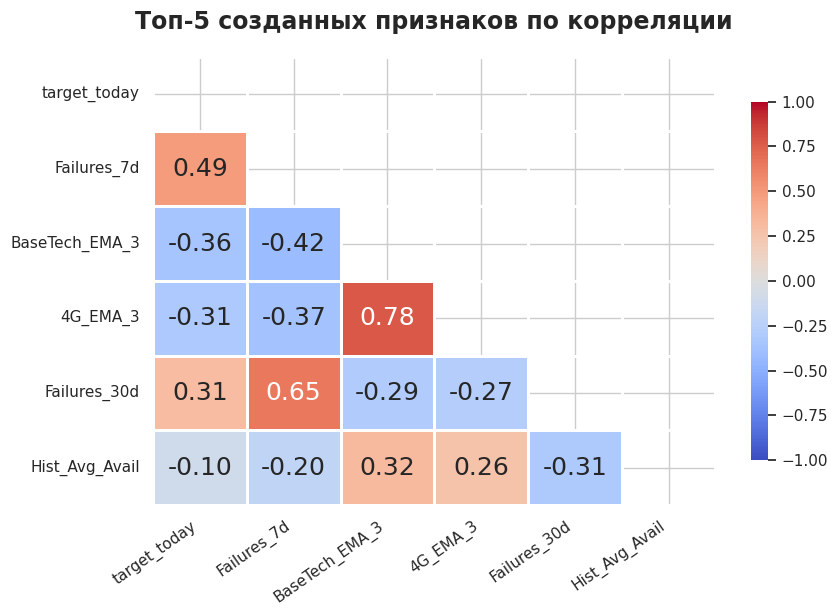

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настраиваем крупный и читаемый шрифт для презентации
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 18, 'axes.labelsize': 8, 'axes.titlesize': 10})

# --- БЛОК СБОРКИ ПРИЗНАКОВ (ПО ВАШЕМУ АНАЛОГУ) ---

# 1. Составные погодные признаки
weather_comp_cols = [
    'Storm_Intensity', 'Ice_Storm_Risk', 'Precip_Extremes',
    'Hail_Impact', 'Winter_Storm', 'Winter_Intense_Precip', 'Summer_Intense_Rain'
]

# 2. Исторические признаки
hist_cols = ['Failures_7d', 'Failures_30d', 'Days_Since_Fail', '4G_EMA_3', 'BaseTech_EMA_3', 'Hist_Avg_Avail']

# 3. Динамический отбор ТОП-5 алармов по корреляции
alarm_cols = [c for c in train_df.columns if c.startswith('Alarm_')]
if alarm_cols:
    top_alarms = train_df[alarm_cols].corrwith(train_df['target_today']).abs().sort_values(ascending=False).head(5).index.tolist()
else:
    top_alarms = []

# Объединяем ВСЕ созданные признаки в один пул
all_new_features = weather_comp_cols + hist_cols + top_alarms

# Валидация: оставляем только те, что есть в датасете и не являются константами (nunique > 1)
all_new_features = [f for f in all_new_features if f in train_df.columns and train_df[f].nunique() > 1]


# --- ОТБОР ТОП-5 ИЗ СГЕНЕРИРОВАННЫХ И ОТРИСОВКА ---

plt.figure(figsize=(9, 6.5))

# Находим ТОП-5 сгенерированных признаков по абсолютному значению корреляции с таргетом
top_5_generated = train_df[all_new_features].corrwith(train_df['target_today']).abs().sort_values(ascending=False).head(5).index.tolist()

# Формируем итоговый набор колонок для матрицы (Таргет + Наш ТОП-5)
cols_to_plot = ['target_today'] + top_5_generated
corr_matrix = train_df[cols_to_plot].corr()

# Срезаем верхний треугольник для чистоты слайда
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Строим компактную тепловую карту
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    cbar_kws={"shrink": .8},
    linewidths=1,
    linecolor='white'
)

plt.title('Топ-5 созданных признаков по корреляции', fontsize=17, pad=20, fontweight='bold')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()